In [ ]:
# DATA MASTERS CHALLENGE 2026
# Task 3: Predictive Modeling
# Binary target: Medal vs No Medal

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")

print("Libraries loaded.")

Libraries loaded.


In [ ]:
uploaded = files.upload()

file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

print("Loaded:", file_name)
print("Shape:", df.shape)
display(df.head())

Saving milan_cortina_2026_modeling_ready.csv to milan_cortina_2026_modeling_ready.csv
Loaded: milan_cortina_2026_modeling_ready.csv
Shape: (387, 34)


,Athlete_ID,Athlete_Name,Country,Gender,Age,Age_Band,Sport,Previous_Olympics,Training_Hours_Per_Week,Altitude_Training_m,Body_Fat_Pct,VO2max,Reaction_Time_ms,Career_Injuries,World_Cup_Points_Preseason,Country_GDP_per_capita,Winter_Sport_Tradition_Index,VO2_BodyFat_Efficiency,Experience_Training_Index,GDP_Tradition_Index,Training_Injury_Burden,Missing_Training_Hours_Per_Week,Missing_Altitude_Training_m,Missing_Body_Fat_Pct,Missing_VO2max,Missing_Reaction_Time_ms,Missing_World_Cup_Points_Preseason,MNAR_Reaction_Time_Missing,MNAR_World_Cup_Points_Missing,Medal_Clean,Medal_Binary,Gold_Binary,Podium_Group,North_America_Rivalry
0,MC26_1001,Ben Ogden,USA,M,26.0,23-27,Cross-Country,1,35.6,1687.0,8.9,91.5,190.0,1,356.0,80000,0.82,10.280899,35.6,65600.0,71.2,0,0,1,0,1,0,1,0,Silver,1,0,Silver/Bronze,USA
1,MC26_1002,Loic Meillard,SUI,M,30.0,28-32,Alpine Skiing,3,22.9,2289.0,13.9,71.4,208.0,1,977.0,93000,0.93,5.136691,68.7,86490.0,45.8,0,0,0,0,0,0,0,0,Gold,1,1,Gold,Other
2,MC26_1003,Francesca Lollobrigida,ITA,F,35.0,33-37,Speed Skating,1,29.0,394.0,10.1,82.6,189.0,3,416.0,38000,0.82,8.178218,29.0,31160.0,116.0,0,0,0,0,0,0,0,0,Gold,1,1,Gold,Other
3,MC26_1004,Maria Nilsson,FRA,F,43.0,38+,Ski Jumping,4,26.2,1239.0,9.1,59.3,183.0,2,801.0,48000,0.87,6.516484,104.8,41760.0,78.6,0,0,0,0,0,0,0,0,NaN,0,0,No Medal,Other
4,MC26_1005,Nils Lewis,GER,M,20.0,Under 23,Short Track,0,20.2,67.0,12.3,63.1,187.0,2,393.0,52000,0.88,5.130081,0.0,45760.0,60.6,0,0,0,0,0,0,0,0,NaN,0,0,No Medal,Other


In [ ]:
print("Medal binary distribution:")
display(df["Medal_Binary"].value_counts())

print("\nMedal binary distribution (%):")
display((df["Medal_Binary"].value_counts(normalize=True) * 100).round(2))

print("\nMedal clean distribution:")
display(df["Medal_Clean"].value_counts())

Medal binary distribution:


,count
Medal_Binary,
0,283
1,104



Medal binary distribution (%):


,proportion
Medal_Binary,
0,73.13
1,26.87



Medal clean distribution:


,count
Medal_Clean,
Gold,49
Silver,32
Bronze,23


In [ ]:
target = "Medal_Binary"

numeric_features = [
    "Age",
    "Previous_Olympics",
    "Training_Hours_Per_Week",
    "Altitude_Training_m",
    "Body_Fat_Pct",
    "VO2max",
    "Reaction_Time_ms",
    "Career_Injuries",
    "World_Cup_Points_Preseason",
    "Country_GDP_per_capita",
    "Winter_Sport_Tradition_Index",
    "VO2_BodyFat_Efficiency",
    "Experience_Training_Index",
    "GDP_Tradition_Index",
    "Training_Injury_Burden",
    "Missing_Training_Hours_Per_Week",
    "Missing_Altitude_Training_m",
    "Missing_Body_Fat_Pct",
    "Missing_VO2max",
    "Missing_Reaction_Time_ms",
    "Missing_World_Cup_Points_Preseason",
    "MNAR_Reaction_Time_Missing",
    "MNAR_World_Cup_Points_Missing"
]

categorical_features = [
    "Country",
    "Gender",
    "Sport",
    "Age_Band",
    "North_America_Rivalry"
]

X = df[numeric_features + categorical_features].copy()
y = df[target].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

display(X.head())

X shape: (387, 28)
y shape: (387,)


,Age,Previous_Olympics,Training_Hours_Per_Week,Altitude_Training_m,Body_Fat_Pct,VO2max,Reaction_Time_ms,Career_Injuries,World_Cup_Points_Preseason,Country_GDP_per_capita,Winter_Sport_Tradition_Index,VO2_BodyFat_Efficiency,Experience_Training_Index,GDP_Tradition_Index,Training_Injury_Burden,Missing_Training_Hours_Per_Week,Missing_Altitude_Training_m,Missing_Body_Fat_Pct,Missing_VO2max,Missing_Reaction_Time_ms,Missing_World_Cup_Points_Preseason,MNAR_Reaction_Time_Missing,MNAR_World_Cup_Points_Missing,Country,Gender,Sport,Age_Band,North_America_Rivalry
0,26.0,1,35.6,1687.0,8.9,91.5,190.0,1,356.0,80000,0.82,10.280899,35.6,65600.0,71.2,0,0,1,0,1,0,1,0,USA,M,Cross-Country,23-27,USA
1,30.0,3,22.9,2289.0,13.9,71.4,208.0,1,977.0,93000,0.93,5.136691,68.7,86490.0,45.8,0,0,0,0,0,0,0,0,SUI,M,Alpine Skiing,28-32,Other
2,35.0,1,29.0,394.0,10.1,82.6,189.0,3,416.0,38000,0.82,8.178218,29.0,31160.0,116.0,0,0,0,0,0,0,0,0,ITA,F,Speed Skating,33-37,Other
3,43.0,4,26.2,1239.0,9.1,59.3,183.0,2,801.0,48000,0.87,6.516484,104.8,41760.0,78.6,0,0,0,0,0,0,0,0,FRA,F,Ski Jumping,38+,Other
4,20.0,0,20.2,67.0,12.3,63.1,187.0,2,393.0,52000,0.88,5.130081,0.0,45760.0,60.6,0,0,0,0,0,0,0,0,GER,M,Short Track,Under 23,Other


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

print("\nTrain target distribution:")
display(y_train.value_counts(normalize=True).round(3))

print("\nTest target distribution:")
display(y_test.value_counts(normalize=True).round(3))

Train size: (309, 28)
Test size: (78, 28)

Train target distribution:


,proportion
Medal_Binary,
0,0.731
1,0.269



Test target distribution:


,proportion
Medal_Binary,
0,0.731
1,0.269


In [ ]:
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=3,
        class_weight="balanced",
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=250,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

pipelines = {}

for name, model in models.items():
    pipelines[name] = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

print("Models created:")
print(list(pipelines.keys()))

Models created:
['Logistic Regression', 'Random Forest', 'Gradient Boosting']


In [ ]:
model_results = []
trained_models = {}

for name, pipe in pipelines.items():
    print("=" * 70)
    print(name)

    pipe.fit(X_train, y_train)
    trained_models[name] = pipe

    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision_macro = precision_score(y_test, y_pred, average="macro", zero_division=0)
    recall_macro = recall_score(y_test, y_pred, average="macro", zero_division=0)
    f1_macro = f1_score(y_test, y_pred, average="macro", zero_division=0)
    f1_weighted = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    auc = roc_auc_score(y_test, y_proba)

    model_results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision_Macro": precision_macro,
        "Recall_Macro": recall_macro,
        "F1_Macro": f1_macro,
        "F1_Weighted": f1_weighted,
        "AUC_ROC": auc
    })

    print(classification_report(y_test, y_pred, target_names=["No Medal", "Medal"], zero_division=0))
    print("AUC:", round(auc, 3))

model_results_df = pd.DataFrame(model_results).sort_values("F1_Macro", ascending=False)

display(model_results_df.round(3))
model_results_df.to_csv("model_metrics_summary.csv", index=False)

Logistic Regression
              precision    recall  f1-score   support

    No Medal       0.85      0.82      0.84        57
       Medal       0.57      0.62      0.59        21

    accuracy                           0.77        78
   macro avg       0.71      0.72      0.72        78
weighted avg       0.78      0.77      0.77        78

AUC: 0.819
Random Forest
              precision    recall  f1-score   support

    No Medal       0.82      0.89      0.86        57
       Medal       0.62      0.48      0.54        21

    accuracy                           0.78        78
   macro avg       0.72      0.69      0.70        78
weighted avg       0.77      0.78      0.77        78

AUC: 0.784
Gradient Boosting
              precision    recall  f1-score   support

    No Medal       0.82      0.95      0.88        57
       Medal       0.75      0.43      0.55        21

    accuracy                           0.81        78
   macro avg       0.78      0.69      0.71        78


,Model,Accuracy,Precision_Macro,Recall_Macro,F1_Macro,F1_Weighted,AUC_ROC
0,Logistic Regression,0.769,0.710,0.722,0.715,0.772,0.819
2,Gradient Boosting,0.808,0.784,0.688,0.712,0.789,0.851
1,Random Forest,0.782,0.724,0.685,0.699,0.772,0.784


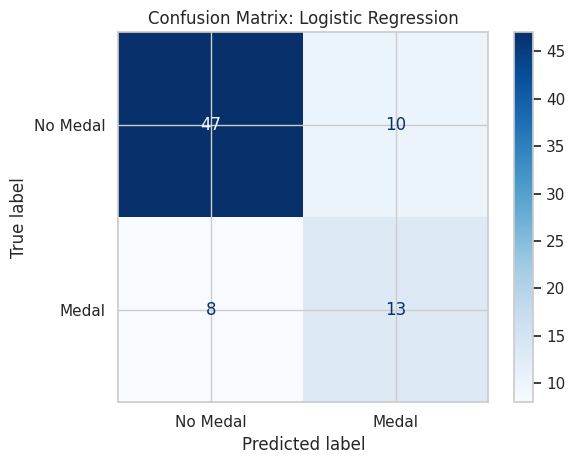

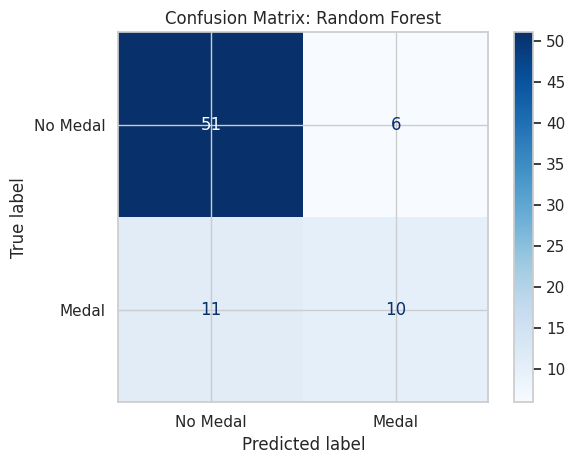

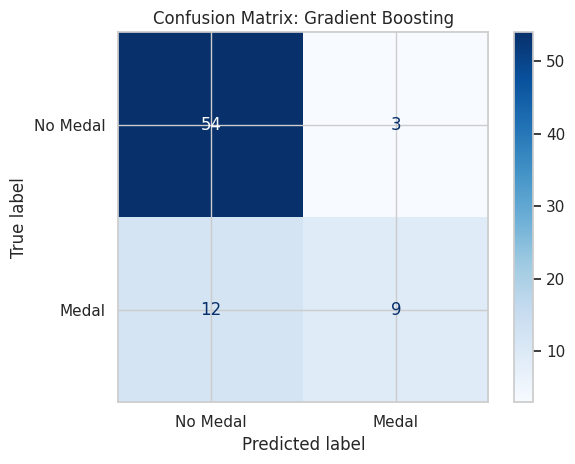

In [ ]:
for name, pipe in trained_models.items():
    y_pred = pipe.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No Medal", "Medal"]
    )

    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix: {name}")
    plt.tight_layout()
    plt.savefig(f"confusion_matrix_{name.replace(' ', '_').lower()}.png", dpi=300)
    plt.show()

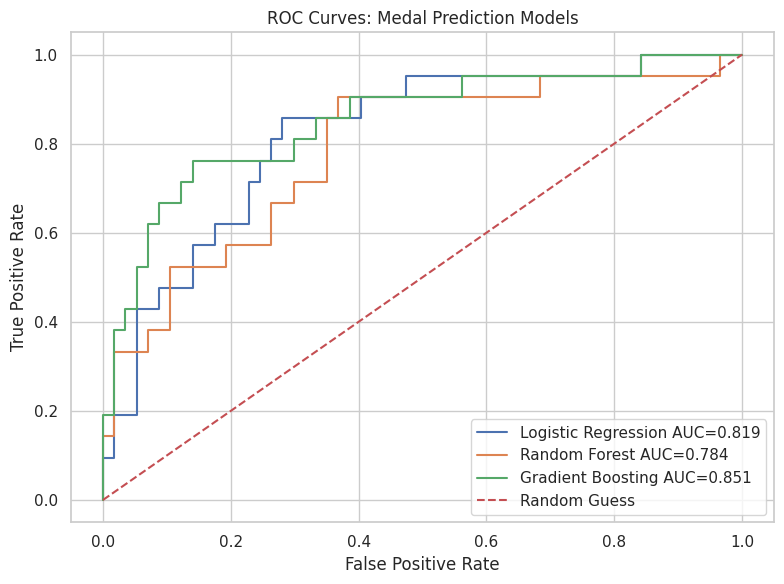

In [ ]:
plt.figure(figsize=(8, 6))

for name, pipe in trained_models.items():
    y_proba = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)

    plt.plot(fpr, tpr, label=f"{name} AUC={auc:.3f}")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")

plt.title("ROC Curves: Medal Prediction Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.savefig("model_roc_curves.png", dpi=300)
plt.show()

In [ ]:
best_model_name = model_results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

print("Best model by Macro F1:", best_model_name)
display(model_results_df.round(3))

Best model by Macro F1: Logistic Regression


,Model,Accuracy,Precision_Macro,Recall_Macro,F1_Macro,F1_Weighted,AUC_ROC
0,Logistic Regression,0.769,0.710,0.722,0.715,0.772,0.819
2,Gradient Boosting,0.808,0.784,0.688,0.712,0.789,0.851
1,Random Forest,0.782,0.724,0.685,0.699,0.772,0.784


In [ ]:
def get_feature_names_from_pipeline(pipe):
    preprocessor = pipe.named_steps["preprocessor"]

    numeric_names = numeric_features

    cat_encoder = preprocessor.named_transformers_["cat"].named_steps["onehot"]
    categorical_names = cat_encoder.get_feature_names_out(categorical_features).tolist()

    return numeric_names + categorical_names

feature_names = get_feature_names_from_pipeline(best_model)

print("Number of final features after encoding:", len(feature_names))
print(feature_names[:20])

Number of final features after encoding: 70
['Age', 'Previous_Olympics', 'Training_Hours_Per_Week', 'Altitude_Training_m', 'Body_Fat_Pct', 'VO2max', 'Reaction_Time_ms', 'Career_Injuries', 'World_Cup_Points_Preseason', 'Country_GDP_per_capita', 'Winter_Sport_Tradition_Index', 'VO2_BodyFat_Efficiency', 'Experience_Training_Index', 'GDP_Tradition_Index', 'Training_Injury_Burden', 'Missing_Training_Hours_Per_Week', 'Missing_Altitude_Training_m', 'Missing_Body_Fat_Pct', 'Missing_VO2max', 'Missing_Reaction_Time_ms']


,Feature,Absolute Coefficient
51,Sport_Cross-Country,2.550774
49,Sport_Biathlon,1.876454
54,Sport_Freestyle Skiing,1.623993
52,Sport_Curling,1.589461
56,Sport_Luge,1.536787
61,Sport_Speed Skating,1.420155
5,VO2max,1.245807
65,Age_Band_38+,1.240558
28,Country_CZE,1.170215
58,Sport_Short Track,0.947008


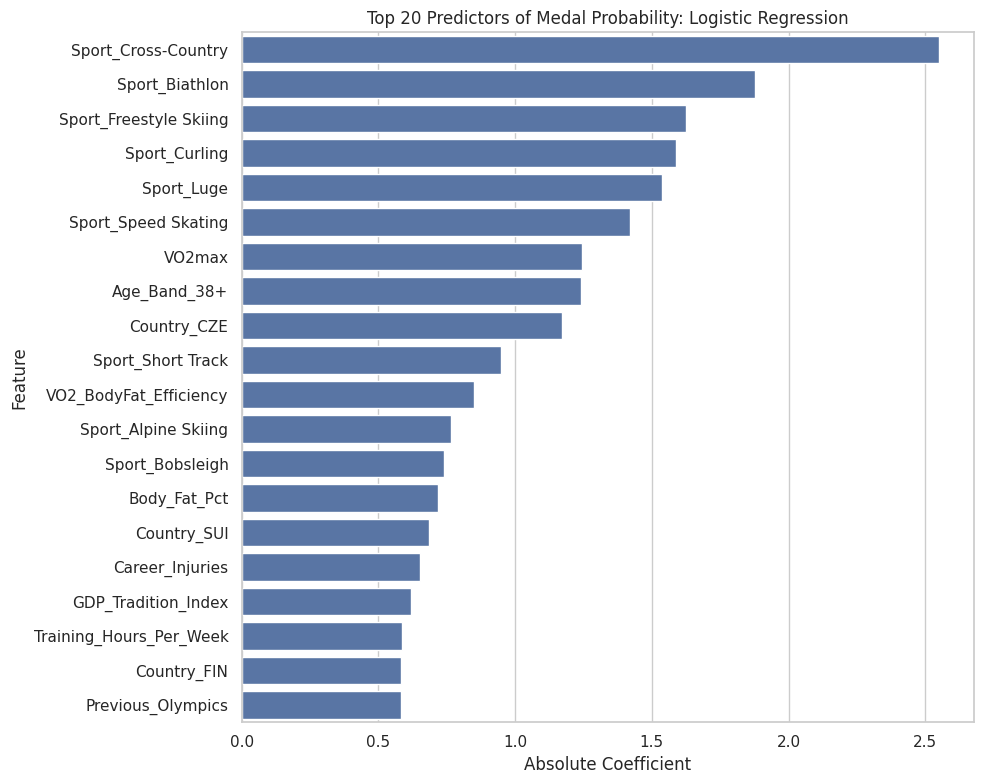

In [ ]:
final_estimator = best_model.named_steps["model"]

if hasattr(final_estimator, "feature_importances_"):
    importance_values = final_estimator.feature_importances_
    importance_type = "Feature Importance"
else:
    importance_values = np.abs(final_estimator.coef_[0])
    importance_type = "Absolute Coefficient"

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    importance_type: importance_values
}).sort_values(importance_type, ascending=False)

display(feature_importance_df.head(25))

feature_importance_df.to_csv("feature_importance_best_model.csv", index=False)

plt.figure(figsize=(10, 8))
sns.barplot(
    data=feature_importance_df.head(20),
    x=importance_type,
    y="Feature"
)
plt.title(f"Top 20 Predictors of Medal Probability: {best_model_name}")
plt.xlabel(importance_type)
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("feature_importance_best_model.png", dpi=300)
plt.show()

,Threshold,Accuracy,Precision_Macro,Recall_Macro,F1_Macro,F1_Weighted
31,0.41,0.756410,0.714583,0.758145,0.723249,0.767464
27,0.37,0.743590,0.722259,0.779449,0.721429,0.757692
25,0.35,0.743590,0.722259,0.779449,0.721429,0.757692
28,0.38,0.743590,0.722259,0.779449,0.721429,0.757692
26,0.36,0.743590,0.722259,0.779449,0.721429,0.757692
24,0.34,0.743590,0.722259,0.779449,0.721429,0.757692
46,0.56,0.782051,0.722414,0.715539,0.718770,0.780341
48,0.58,0.782051,0.722414,0.715539,0.718770,0.780341
47,0.57,0.782051,0.722414,0.715539,0.718770,0.780341
33,0.43,0.756410,0.707857,0.743108,0.717337,0.765842


Best threshold by Macro F1: 0.41


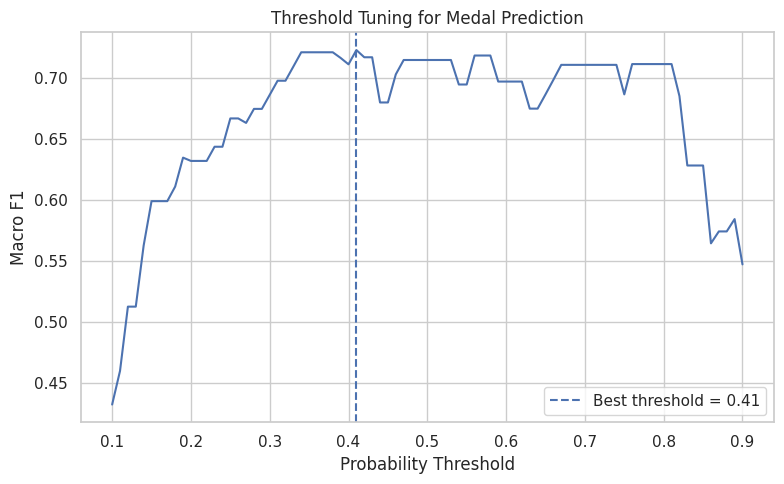

In [ ]:
y_test_proba = best_model.predict_proba(X_test)[:, 1]

threshold_rows = []

for threshold in np.arange(0.10, 0.91, 0.01):
    y_pred_threshold = (y_test_proba >= threshold).astype(int)

    threshold_rows.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, y_pred_threshold),
        "Precision_Macro": precision_score(y_test, y_pred_threshold, average="macro", zero_division=0),
        "Recall_Macro": recall_score(y_test, y_pred_threshold, average="macro", zero_division=0),
        "F1_Macro": f1_score(y_test, y_pred_threshold, average="macro", zero_division=0),
        "F1_Weighted": f1_score(y_test, y_pred_threshold, average="weighted", zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_rows)
best_threshold_row = threshold_df.sort_values("F1_Macro", ascending=False).iloc[0]
best_threshold = best_threshold_row["Threshold"]

display(threshold_df.sort_values("F1_Macro", ascending=False).head(10))

print("Best threshold by Macro F1:", round(best_threshold, 2))

threshold_df.to_csv("threshold_tuning_results.csv", index=False)

plt.figure(figsize=(8, 5))
sns.lineplot(data=threshold_df, x="Threshold", y="F1_Macro")
plt.axvline(best_threshold, linestyle="--", label=f"Best threshold = {best_threshold:.2f}")
plt.title("Threshold Tuning for Medal Prediction")
plt.xlabel("Probability Threshold")
plt.ylabel("Macro F1")
plt.legend()
plt.tight_layout()
plt.savefig("threshold_tuning_macro_f1.png", dpi=300)
plt.show()

Best Model: Logistic Regression
Tuned Threshold: 0.41
              precision    recall  f1-score   support

    No Medal       0.90      0.75      0.82        57
       Medal       0.53      0.76      0.63        21

    accuracy                           0.76        78
   macro avg       0.71      0.76      0.72        78
weighted avg       0.80      0.76      0.77        78



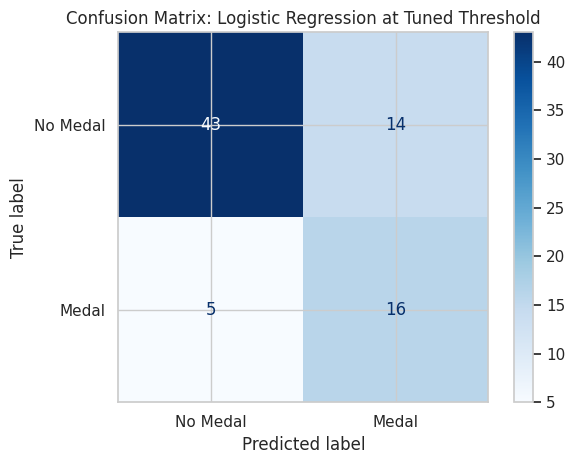

In [ ]:
y_pred_tuned = (y_test_proba >= best_threshold).astype(int)

print("Best Model:", best_model_name)
print("Tuned Threshold:", round(best_threshold, 2))

print(classification_report(y_test, y_pred_tuned, target_names=["No Medal", "Medal"], zero_division=0))

cm = confusion_matrix(y_test, y_pred_tuned)
disp = ConfusionMatrixDisplay(cm, display_labels=["No Medal", "Medal"])
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix: {best_model_name} at Tuned Threshold")
plt.tight_layout()
plt.savefig("confusion_matrix_best_model_tuned_threshold.png", dpi=300)
plt.show()

In [ ]:
test_athlete_names = [
    "Jordan Stolz",
    "Mikaela Shiffrin",
    "Connor McDavid",
    "Courtney Sarault",
    "Elana Meyers Taylor",
    "Deanna Stellato-Dudek",
    "Metodej Jilek"
]

# Flexible matching in case of punctuation or abbreviations
prediction_test_df = df[
    df["Athlete_Name"].isin(test_athlete_names)
].copy()

print("Found athletes:", prediction_test_df.shape[0])
display(prediction_test_df[[
    "Athlete_Name", "Country", "Sport", "Age", "Medal_Clean",
    "World_Cup_Points_Preseason", "Previous_Olympics",
    "Training_Hours_Per_Week", "VO2max"
]])

Found athletes: 7


,Athlete_Name,Country,Sport,Age,Medal_Clean,World_Cup_Points_Preseason,Previous_Olympics,Training_Hours_Per_Week,VO2max
20,Jordan Stolz,USA,Speed Skating,22.0,Gold,571.0,1,31.8,83.1
53,Connor McDavid,CAN,Ice Hockey,29.0,Silver,587.5,4,23.7,64.9
54,Metodej Jilek,CZE,Speed Skating,20.0,Gold,1244.0,5,28.8,81.3
75,Courtney Sarault,CAN,Short Track,27.0,Silver,536.0,2,29.6,72.9
109,Deanna Stellato-Dudek,CAN,Figure Skating,43.0,NaN,587.5,3,29.3,55.2
272,Elana Meyers Taylor,USA,Bobsleigh,42.0,Gold,293.0,3,25.2,73.3
328,Mikaela Shiffrin,USA,Alpine Skiing,31.0,Gold,823.0,1,27.2,81.2


In [ ]:
search_terms = ["Stolz", "Shiffrin", "McDavid", "Sarault", "Meyers", "Stellato", "Jilek"]

for term in search_terms:
    print(f"\nMatches for {term}:")
    display(df[df["Athlete_Name"].str.contains(term, case=False, na=False)][
        ["Athlete_Name", "Country", "Sport", "Age", "Medal_Clean"]
    ])


Matches for Stolz:


,Athlete_Name,Country,Sport,Age,Medal_Clean
20,Jordan Stolz,USA,Speed Skating,22.0,Gold



Matches for Shiffrin:


,Athlete_Name,Country,Sport,Age,Medal_Clean
328,Mikaela Shiffrin,USA,Alpine Skiing,31.0,Gold



Matches for McDavid:


...

,Athlete_Name,Country,Sport,Age,Medal_Clean
272,Elana Meyers Taylor,USA,Bobsleigh,42.0,Gold



Matches for Stellato:


,Athlete_Name,Country,Sport,Age,Medal_Clean
109,Deanna Stellato-Dudek,CAN,Figure Skating,43.0,NaN



Matches for Jilek:


,Athlete_Name,Country,Sport,Age,Medal_Clean
54,Metodej Jilek,CZE,Speed Skating,20.0,Gold


In [ ]:
# Use the exact found rows
X_prediction_test = prediction_test_df[numeric_features + categorical_features].copy()

prediction_test_df["Predicted_Medal_Probability"] = best_model.predict_proba(X_prediction_test)[:, 1]
prediction_test_df["Predicted_Class_0p50"] = (prediction_test_df["Predicted_Medal_Probability"] >= 0.50).astype(int)
prediction_test_df["Predicted_Class_Tuned"] = (prediction_test_df["Predicted_Medal_Probability"] >= best_threshold).astype(int)

prediction_test_df["Predicted_Label_0p50"] = prediction_test_df["Predicted_Class_0p50"].map({
    0: "No Medal",
    1: "Medal"
})

prediction_test_df["Predicted_Label_Tuned"] = prediction_test_df["Predicted_Class_Tuned"].map({
    0: "No Medal",
    1: "Medal"
})

prediction_test_output = prediction_test_df[[
    "Athlete_Name",
    "Country",
    "Sport",
    "Age",
    "Medal_Clean",
    "Predicted_Medal_Probability",
    "Predicted_Class_Tuned", # Added this line
    "Predicted_Label_0p50",
    "Predicted_Label_Tuned",
    "World_Cup_Points_Preseason",
    "Previous_Olympics",
    "Training_Hours_Per_Week",
    "VO2max",
    "MNAR_World_Cup_Points_Missing",
    "MNAR_Reaction_Time_Missing"
]].sort_values("Predicted_Medal_Probability", ascending=False)

display(prediction_test_output)

prediction_test_output.to_csv("usa_can_prediction_test_results.csv", index=False)

,Athlete_Name,Country,Sport,Age,Medal_Clean,Predicted_Medal_Probability,Predicted_Class_Tuned,Predicted_Label_0p50,Predicted_Label_Tuned,World_Cup_Points_Preseason,Previous_Olympics,Training_Hours_Per_Week,VO2max,MNAR_World_Cup_Points_Missing,MNAR_Reaction_Time_Missing
328,Mikaela Shiffrin,USA,Alpine Skiing,31.0,Gold,0.969813,1,Medal,Medal,823.0,1,27.2,81.2,0,0
54,Metodej Jilek,CZE,Speed Skating,20.0,Gold,0.921005,1,Medal,Medal,1244.0,5,28.8,81.3,0,0
20,Jordan Stolz,USA,Speed Skating,22.0,Gold,0.914008,1,Medal,Medal,571.0,1,31.8,83.1,1,0
272,Elana Meyers Taylor,USA,Bobsleigh,42.0,Gold,0.820737,1,Medal,Medal,293.0,3,25.2,73.3,1,1
75,Courtney Sarault,CAN,Short Track,27.0,Silver,0.660883,1,Medal,Medal,536.0,2,29.6,72.9,1,0
109,Deanna Stellato-Dudek,CAN,Figure Skating,43.0,NaN,0.274349,0,No Medal,No Medal,587.5,3,29.3,55.2,1,1
53,Connor McDavid,CAN,Ice Hockey,29.0,Silver,0.260602,0,No Medal,No Medal,587.5,4,23.7,64.9,1,0


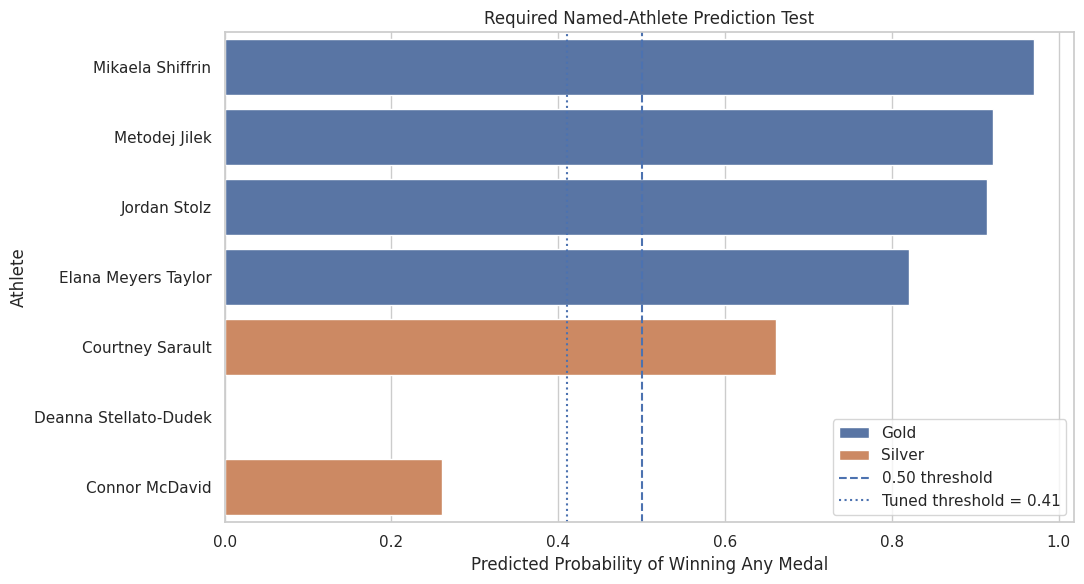

In [ ]:
plt.figure(figsize=(11, 6))

sns.barplot(
    data=prediction_test_output,
    x="Predicted_Medal_Probability",
    y="Athlete_Name",
    hue="Medal_Clean",
    dodge=False
)

plt.axvline(0.50, linestyle="--", label="0.50 threshold")
plt.axvline(best_threshold, linestyle=":", label=f"Tuned threshold = {best_threshold:.2f}")

plt.title("Required Named-Athlete Prediction Test")
plt.xlabel("Predicted Probability of Winning Any Medal")
plt.ylabel("Athlete")
plt.legend()
plt.tight_layout()
plt.savefig("named_athlete_prediction_test.png", dpi=300)
plt.show()

In [ ]:
def prediction_interpretation(row):
    actual_medalist = row["Medal_Clean"] != "None"
    predicted_medalist = row["Predicted_Class_Tuned"] == 1

    if actual_medalist and predicted_medalist:
        result = "Correct high-risk/high-performance identification: the model predicted a medal and the athlete won a medal."
    elif (not actual_medalist) and (not predicted_medalist):
        result = "Correct non-medalist identification: the model predicted no medal and the athlete did not medal."
    elif actual_medalist and (not predicted_medalist):
        result = "False negative: the model underpredicted this athlete's medal success."
    else:
        result = "False positive: the model predicted medal potential, but the athlete did not medal."

    explanation_parts = []

    if row["World_Cup_Points_Preseason"] > df["World_Cup_Points_Preseason"].median():
        explanation_parts.append("above-median preseason World Cup points")
    else:
        explanation_parts.append("below-median or imputed preseason World Cup points")

    if row["Previous_Olympics"] > df["Previous_Olympics"].median():
        explanation_parts.append("strong Olympic experience")
    else:
        explanation_parts.append("limited Olympic experience")

    if row["Age"] >= 38:
        explanation_parts.append("an age-outlier profile")
    elif row["Age"] <= 21:
        explanation_parts.append("a very young athlete profile")
    else:
        explanation_parts.append("a prime-age athlete profile")

    if row["MNAR_World_Cup_Points_Missing"] == 1:
        explanation_parts.append("sport-systematic missing World Cup points")

    return result + " Key model signals: " + ", ".join(explanation_parts) + "."

prediction_test_output["Model_Interpretation_Note"] = prediction_test_output.apply(prediction_interpretation, axis=1)

display(prediction_test_output[[
    "Athlete_Name",
    "Medal_Clean",
    "Predicted_Medal_Probability",
    "Predicted_Label_Tuned",
    "Model_Interpretation_Note"
]])

prediction_test_output.to_csv("usa_can_prediction_test_with_interpretations.csv", index=False)

,Athlete_Name,Medal_Clean,Predicted_Medal_Probability,Predicted_Label_Tuned,Model_Interpretation_Note
328,Mikaela Shiffrin,Gold,0.969813,Medal,Correct high-risk/high-performance identificat...
54,Metodej Jilek,Gold,0.921005,Medal,Correct high-risk/high-performance identificat...
20,Jordan Stolz,Gold,0.914008,Medal,Correct high-risk/high-performance identificat...
272,Elana Meyers Taylor,Gold,0.820737,Medal,Correct high-risk/high-performance identificat...
75,Courtney Sarault,Silver,0.660883,Medal,Correct high-risk/high-performance identificat...
109,Deanna Stellato-Dudek,NaN,0.274349,No Medal,False negative: the model underpredicted this ...
53,Connor McDavid,Silver,0.260602,No Medal,False negative: the model underpredicted this ...


Missing in X: 0
Missing in y: 0

Class distribution:
Medal_Clean
None      283
Gold       49
Silver     32
Bronze     23
Name: count, dtype: int64
              precision    recall  f1-score   support

      Bronze       0.00      0.00      0.00         5
        Gold       0.43      0.30      0.35        10
        None       0.77      0.95      0.85        57
      Silver       0.00      0.00      0.00         6

    accuracy                           0.73        78
   macro avg       0.30      0.31      0.30        78
weighted avg       0.62      0.73      0.67        78



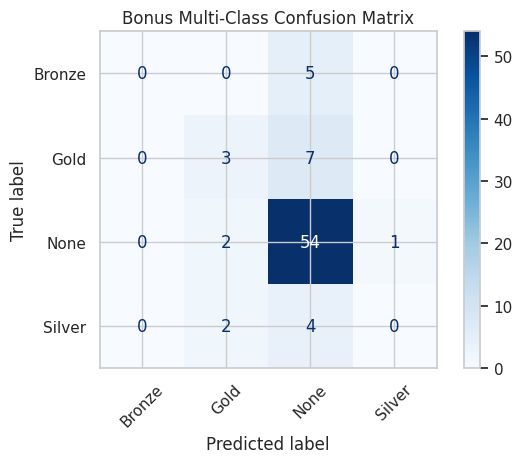

In [ ]:
# Multi-class classification
# Predicting Gold / Silver / Bronze / None

multi_target = "Medal_Clean"

# Make sure target has no NaN
df[multi_target] = df[multi_target].fillna("None")

X_multi = df[numeric_features + categorical_features].copy()
y_multi = df[multi_target].copy()

# Safety check
print("Missing in X:", X_multi.isna().sum().sum())
print("Missing in y:", y_multi.isna().sum())
print("\nClass distribution:")
print(y_multi.value_counts())

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi,
    y_multi,
    test_size=0.20,
    random_state=42,
    stratify=y_multi
)

multi_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=500,
        min_samples_leaf=3,
        class_weight="balanced",
        random_state=42
    ))
])

multi_model.fit(X_train_m, y_train_m)

y_pred_m = multi_model.predict(X_test_m)

print(classification_report(y_test_m, y_pred_m, zero_division=0))

labels = multi_model.named_steps["model"].classes_

multi_cm = confusion_matrix(y_test_m, y_pred_m, labels=labels)

disp = ConfusionMatrixDisplay(
    confusion_matrix=multi_cm,
    display_labels=labels
)

disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Bonus Multi-Class Confusion Matrix")
plt.tight_layout()
plt.savefig("bonus_multiclass_confusion_matrix.png", dpi=300)
plt.show()

multi_results = pd.DataFrame({
    "Actual": y_test_m,
    "Predicted": y_pred_m
})

multi_results.to_csv("bonus_multiclass_predictions.csv", index=False)

In [ ]:
# Save all key outputs
model_results_df.to_csv("model_metrics_summary.csv", index=False)
feature_importance_df.to_csv("feature_importance_best_model.csv", index=False)
threshold_df.to_csv("threshold_tuning_results.csv", index=False)
prediction_test_output.to_csv("usa_can_prediction_test_with_interpretations.csv", index=False)

print("Saved modeling outputs:")
print("- model_metrics_summary.csv")
print("- feature_importance_best_model.csv")
print("- threshold_tuning_results.csv")
print("- usa_can_prediction_test_with_interpretations.csv")
print("- model_roc_curves.png")
print("- feature_importance_best_model.png")
print("- named_athlete_prediction_test.png")

Saved modeling outputs:
- model_metrics_summary.csv
- feature_importance_best_model.csv
- threshold_tuning_results.csv
- usa_can_prediction_test_with_interpretations.csv
- model_roc_curves.png
- feature_importance_best_model.png
- named_athlete_prediction_test.png


In [ ]:
output_files = [
    "model_metrics_summary.csv",
    "feature_importance_best_model.csv",
    "threshold_tuning_results.csv",
    "usa_can_prediction_test_results.csv",
    "usa_can_prediction_test_with_interpretations.csv",
    "model_roc_curves.png",
    "feature_importance_best_model.png",
    "threshold_tuning_macro_f1.png",
    "named_athlete_prediction_test.png",
    "confusion_matrix_best_model_tuned_threshold.png"
]

for f in output_files:
    try:
        files.download(f)
    except:
        print("Could not download:", f)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>